# Training + Inference for Models

In [166]:
import pandas as pd 

data_filepath = "data/processed_data.csv"
df = pd.read_csv(data_filepath, index_col=0)

df.head()

,cp_1,cp_2,cp_3,cp_4,restecg_0,restecg_1,restecg_2,slope_1,slope_2,slope_3,...,age,trestbps,chol,thalach,oldpeak,ca,sex,fbs,exang,num
0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,...,0.967884,0.966617,-0.226405,0.000000,1.299011,-0.717120,1.0,1.0,0.0,0.0
1,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,...,1.406469,1.930000,0.956100,-1.851258,0.521353,2.587179,1.0,0.0,1.0,1.0
2,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,...,1.406469,-0.639021,-0.315650,-0.925629,1.590633,1.485746,1.0,0.0,1.0,1.0
3,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,-1.882917,0.003234,0.152889,1.630871,2.465498,-0.717120,1.0,0.0,0.0,0.0
4,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,...,-1.444332,0.003234,-0.873435,0.969707,0.424145,-0.717120,0.0,0.0,0.0,0.0


In [167]:
# Split dataset in features & target variables 
feature_cols = ['cp_1', 'cp_2', 'cp_3', 'cp_4', 'restecg_0', 'restecg_1', 'restecg_2',
       'slope_1', 'slope_2', 'slope_3', 'thal_3.0', 'thal_6.0', 'thal_7.0',
       'age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca', 'sex', 'fbs',
       'exang']

X = df[feature_cols]
y = df['num']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.3,
                                                    stratify=y, #so the train and test sets have the same proportion of heart disease cases.
                                                    random_state=42)


## Logistic Regression (Baseline)

### Logistic Regression refresher

- Logistic Regression is a statistical method for predicting binary classes 
- The outcome or target variable is dichotomous (only two possible classes)
- It is a special case of linear regression where the target variable is categorical 
- It uses a log of odds as the dependent variable 
- Logisitic regression predicts the probability of occurrence of a binary event utilizing a logit function 


Linear Regression:
$$
y = \beta_0 + \beta_1X_1 + \beta_2X_2 + \dots + \beta_nX_n
$$

Sigmoid function: 
$$
p = \frac{1}{1+e^{-y}}
$$

Applying sigmoid function on linear regression:
$$
p = \frac{1}{1+e^{-(\beta_0 + \beta_1X_1 + \beta_2X_2 + \dots + \beta_nX_n
)}}
$$

Splitting data in a (70/30) split

### Model Development & Selection

In [169]:
from sklearn.linear_model import LogisticRegression

# Instantiate the model (using default params)
logreg_model = LogisticRegression(random_state=42)

#Fit model with data 
logreg_model.fit(X_train, y_train)


,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",42
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following a

In the default parameters for Logistic Regression the solver used is `lbfgs`

The solver is the algorithm to use in the optimization problem. There are other solver options to use are: 
- ‘lbfgs’ is a good default solver because it works reasonably well for a wide class of problems.

- For multiclass problems (n_classes >= 3), all solvers except ‘liblinear’ minimize the full multinomial loss, ‘liblinear’ will raise an error.

- ‘newton-cholesky’ is a good choice for n_samples >> n_features * n_classes, especially with one-hot encoded categorical features with rare categories. Be aware that the memory usage of this solver has a quadratic dependency on n_features * n_classes because it explicitly computes the full Hessian matrix.

- For small datasets, ‘liblinear’ is a good choice, whereas ‘sag’ and ‘saga’ are faster for large ones;

- ‘liblinear’ can only handle binary classification by default. To apply a one-versus-rest scheme for the multiclass setting one can wrap it with the OneVsRestClassifier.

From the descriptions, another possible solver to use is the newton-cholesky solver and we can test any improvements 

</br>

> Resource: https://scikit-learn.org/1.9/modules/generated/sklearn.linear_model.LogisticRegression.html -> solver parameter

In [189]:
import time 
from sklearn.metrics import log_loss

solvers = ['lbfgs', 'newton-cholesky']
results = []

for solver in solvers:
    model= LogisticRegression(solver=solver, max_iter=200, random_state=42)

    # Track time to fit on train data
    start_time = time.time()
    model.fit(X_train, y_train)
    elapsed = time.time() - start_time

    # Predict probabilites 
    y_prob_train = model.predict_proba(X_train)
    train_loss = log_loss(y_train, y_prob_train)

    # Extract actual iterations taken per model
    iterations = model.n_iter_[0] if len(model.n_iter_) == 1 else model.n_iter_

    results.append({
        'Solver': solver, 
        'Train log loss': round(train_loss, 6), 
        'Iterations Taken': iterations, 
        'Time (s)': round(elapsed, 4)
    })

results = pd.DataFrame(results)
print(results)

            Solver  Train log loss  Iterations Taken  Time (s)
0            lbfgs        0.338653                24    0.0176
1  newton-cholesky        0.338669                 4    0.0078


Both solvers reach the same solution, and newton-cholesky needs fewer iterations and takes less time. Since it's a minor improvement either solver works.

### Hyperparameter Tuning

In [190]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, fbeta_score
import warnings

# Block warnings
warnings.filterwarnings('ignore')

# Parameter Grid to explore 
param_grid_lg = {
    'C' : [0.01, 0.1, 1, 10, 100], 
    'penalty' : ['l2'], 
    'solver': ['newton-cholesky']
}

f2 = make_scorer(fbeta_score, beta=2)

logreg_model = LogisticRegression(max_iter=200)
grid_search_logreg = GridSearchCV(
    estimator=logreg_model, 
    param_grid=param_grid_lg, 
    cv=5, # Cross Validation strategy, default is 5-fold cross validation
    scoring=f2, 
    error_score="raise"
)
grid_search_logreg.fit(X_train, y_train)
print('Best Parameters:', grid_search_logreg.best_params_)
print("Best Score:", grid_search_logreg.best_score_)

Best Parameters: {'C': 0.1, 'penalty': 'l2', 'solver': 'newton-cholesky'}
Best Score: 0.7631124860622379


### Evaluation

Recall: 0.8108108108108109
Precision: 0.8823529411764706
Accuracy: 0.8690476190476191


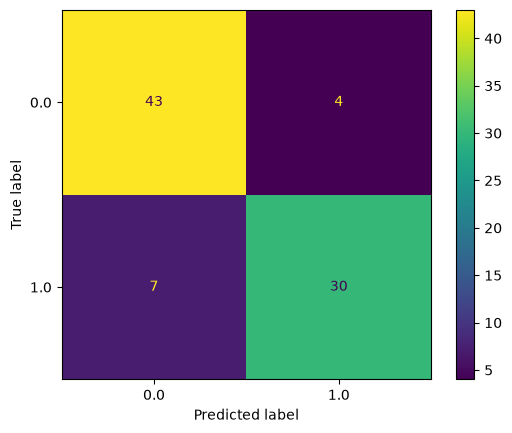

In [191]:
from sklearn.metrics import recall_score, accuracy_score, precision_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred_lg = grid_search_logreg.predict(X_test)


recall_lg = recall_score(y_test, y_pred_lg)
precision_lg = precision_score(y_test, y_pred_lg)
accuracy_lg = accuracy_score(y_test, y_pred_lg)
print('Recall:', recall_lg)
print('Precision:', precision_lg)
print('Accuracy:', accuracy_lg)
cm = confusion_matrix(y_test, y_pred_lg)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=grid_search_logreg.classes_)
disp.plot()

In [192]:
#Save model 
from joblib import dump, load

dump(grid_search_logreg, 'models/logistic.joblib')

# To load model back 
#loaded_model = load('logistic.joblib')

['models/logistic.joblib']

## Random Forest Model

### Random Forest refresher
- Random Forest uses many decision trees to make better predictions
    - Each tree looks at different random parts of the data and their results are combined by voting for classification or averaging for regression (makes RF an ensemble learning technique)
    - This helps improving accuracy and reducing errors

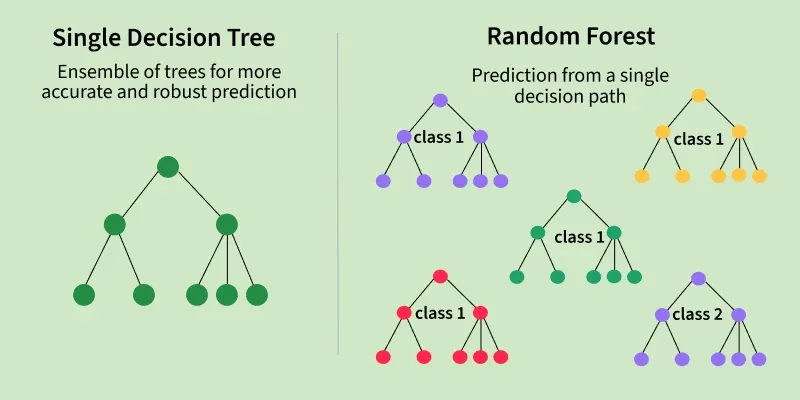

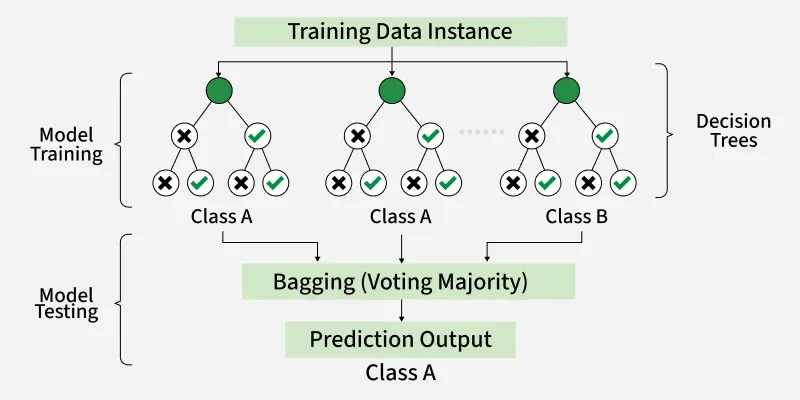

- Random Forest Algorithm
    1. Create many decision trees: The algorithm makes many decision trees each using a random part of the data, so every tree is a bit different.
    2. Pick random features: When building each tree it doesn't look at all the features at once. It picks a few at random to decide how to split the data
    3. Each tree makes a prediction: Every tree gives its own answer or prediction based on what it learned from its part of the data 
    4. Combine the predictions: For classification, the final answer is the category that most trees vote for (majority voting)
    5. Why it works well: Using random data and features for each tree helps avoid overfitting and makes the overall prediction better

- Assumptions of Random Forest:
    - Each tree makes its own decision: Every tree in the forest makes its own predictions without relying on others.
    - Random parts of the data are used: Each tree is built using random samples and features to reduce mistakes.
    - Enough data is needed: Sufficient data ensures the trees are different and learn unique patterns and variety.
    - Different predictions improve accuracy: Combining the predictions from different tress leads to a more accurate final result

</br>

> Resource: https://www.geeksforgeeks.org/machine-learning/random-forest-algorithm-in-machine-learning/

### Model Development & Selection

In [174]:
from sklearn.ensemble import RandomForestClassifier

rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)

rf_classifier.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

### Hyperparameter Tuning

Random Forest Hyperparameters: 
  - `n_estimators`: Defines the number of tress in the forest. More trees typically improve model performance but increase computation cost
  - `max_features`: Limits the number of features to consider when splitting a node. Helps control overfitting
    - sqrt: Selects the square root of the total features. Common setting to reduce overfitting and speed up the model.
    - log2: Selects the base-2 logarithm of the total number of features. It provides more randomness and reduces overfitting more than the square root option.
    -  None: If None is chosen the model uses all available features for splitting each node. This increases the model's complexity and may cause overfitting, especially with many features.
  - `max_depth`: Limits the maximum depth of each tree. Shallow tree may underfit while a deep tree may overfit.
  - `max_leaf_nodes`: Limits the number of leaf nodes in the tree (controls its size and complexity)
  - `max_samples`: Determines how much of the dataset is given to each individual tree
  - `min_samples_split`: Specifies the minimum number of samples required to split an internal node

In [188]:
from sklearn.model_selection import GridSearchCV
import warnings
from math import sqrt, log2
from sklearn.metrics import make_scorer, fbeta_score


#Block Warnings 
warnings.filterwarnings('ignore')

param_grid_rf = {
    'n_estimators': [50, 100, 250, 500],
    'max_features': [int(sqrt(len(X.columns))), int(log2(len(X.columns))), len(X.columns)], 
    'max_leaf_nodes': [None, 16, 32],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'bootstrap': [True, False]
}

f2 = make_scorer(fbeta_score, beta=2)

grid_search_rf = GridSearchCV(
    estimator=RandomForestClassifier(),
    param_grid=param_grid_rf, 
    cv = 5, 
    scoring=f2,
    error_score="raise"
)

grid_search_rf.fit(X_train, y_train)
print('Best Parameters:', grid_search_rf.best_params_)
print("Best Score:", grid_search_rf.best_score_)


Best Parameters: {'bootstrap': False, 'max_features': 4, 'max_leaf_nodes': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best Score: 0.7778493569424803


### Evaluation

Recall: 0.7567567567567568
Precision: 0.875
Accuracy: 0.8452380952380952


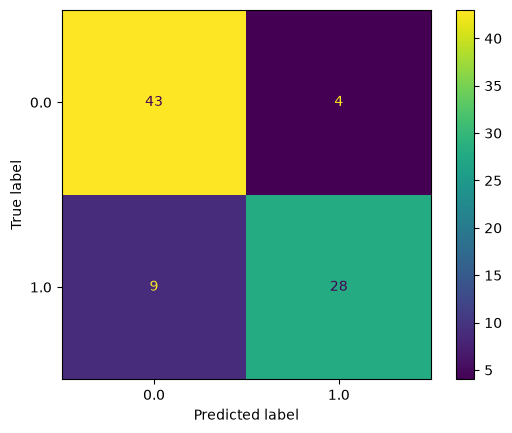

In [193]:
from sklearn.metrics import recall_score, accuracy_score, precision_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred_rf = grid_search_rf.predict(X_test)

recall_rf = recall_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
accuracy_rf = accuracy_score(y_test, y_pred_rf)

print('Recall:', recall_rf)
print('Precision:', precision_rf)
print('Accuracy:', accuracy_rf)
cm = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=grid_search_rf.classes_)
disp.plot()

In [194]:
#Save model 
from joblib import dump, load

dump(grid_search_rf, 'models/randomforest.joblib')

# To load model back 
#loaded_model = load('randomforest.joblib')

['models/randomforest.joblib']

## XGBoost Model

### XGBoost refresher
- XGBoost is an optimized gradient boosting algorithm that combines multiple weak models into a stronger, high-performance model.
    - It uses decision trees as base learners, building them sequentially so each tree corrects errors from the previous one, and it is known as boosting
    - It features parallel processing for faster training on large datasets and allows parameter customization to optimize performance for specific problems. 

    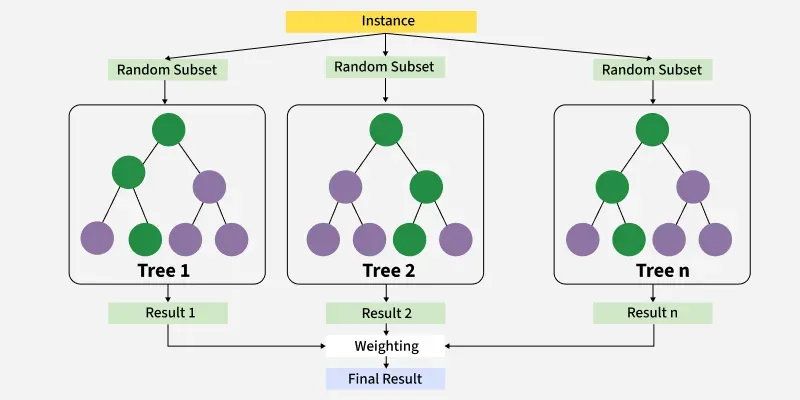

- XGBoost Algorithm: 
    1. Start with a base learner: The first model decision tree is trained on the data. For regression tasks this base model simply predicts the average of the target variable
    2. Calculate the errors: After training the first tree the errors between the predicted and actual values are calculated
    3. Train the next tree: The next tree is trained on the errors of the previous tree. This step attempts to correct the errors made by the first tree. 
    4. Repeat the process: This process continues with each new tree trying to correct the errors of the previous trees until a stopping criterion is met.
    5. Combine the predictions: The final prediction is the sum of predictions from all the trees.

- Mathematics behind the XGBoost Algorithm
    - The algorithm can be seen as a iterative process where we start with an initial prediction (often set to zero). After which each tree is added to reduce errors.
    - Mathematically, the model can be represented as: $$ \hat{y}_i = \sum_{k=1}^{K}f_k(x_i)$$ where
        - $\hat{y}_i $ is the final predicted value for the $i^{th}$ data point 
        - $K$ is the number of trees in the ensemble
        - $f_k(x_i)$ represents the prediction of the $K^{th}$ tree for the $i^{th}$ data point

    </br> 

    1. The objective function in XGBoost consists of two parts (a loss function and a regularization term). The loss function determines how well the model fits the data and the regularization term simplifies complex trees. The general form of the loss function is: $$ obj(\theta) = \sum^{i}_{n} l(y_i, \hat{y}_i) + \sum_{k=1}^{K}\Omega(f_k)$$
    where
        - $l(y_i, \hat{y}_i)$ is the loss function that computes the difference between the true value $y_i$ and the predicted value $\hat{y}_i$
        - $\Omega(f_k)$ is the regularization term which discourages overly complex trees

    2. Instead of fitting the model all at once, we optimize the model iteratively. We start with an initial prediction $\hat{y_i}^{(0)} = 0$ and at each step we add a new tree to improve the model. The updated predictions after adding the $t^{th}$ tree can be written as: $$ \hat{y_i}^{(t)} = \hat{y_i}^{(t-1)} + f_t(x_i) $$ where 
        - $ \hat{y_i}^{(t-1)}$ is the prediction from the previous iteration.
        - $f_t(x_i)$ is the prediction of the $t^{th}$ tree for the $i^{th}$ data point.

    3. The regularization term $\Omega(f_t)$ simplify complex trees by penalizing the number of leaves in the tree and the size of the lead. It as defined as: $$ \Omega(f_t) = \gamma T + \frac{1}{2} \lambda \sum_{j=1}^{T}w_j^2$$ where
        - $T$ is the number of leaves in the tree
        - $\gamma$ is a regularization parameter that controls the complexity of the tree
        - $\lambda$ is a parameter that penalizes the squared weight of the leaves $w_j$
    
    4. Finally, when deciding how to split the nodes in the tree we compute the information gain for every possible split. The information gain is calculated as: $$ Gain=\frac12\left\lbrack\frac{G_{L^{}}^2}{H_{L}+\lambda}+\frac{G_{R^{}}^2}{H_{R}+\lambda}-\frac{\left(G_{L^{}}^{}+G_{R}\right)^2}{H_{L}+H_{R}+\lambda}\right\rbrack-\gamma $$ where 
        - $G_L, G_R$ are the sum of gradients in the left and right child nodes
        - $H_L, H_R$ are the sum of Hessians in the left and right child nodes
    
        By calculating the information gain for every possible split at each node XGBoost selects the split that results in the largest gain which effectively reduces the errors and improves the model's performance

</br>

> Resource: https://www.geeksforgeeks.org/machine-learning/xgboost/

> Resource: https://www.datacamp.com/tutorial/xgboost-in-python

### Model Development & Selection

XGBoost comes with its own class for storing datasets called DMatrix. It is a highly optimized class for memory and speed. That's why converting datasets into this format is a requirement for the native XGBoost API

In [178]:
import xgboost as xgb

dtrain = xgb.DMatrix(X_train, y_train, enable_categorical=True)
dtest = xgb.DMatrix(X_test, y_test, enable_categorical=True)

In [ ]:
import xgboost as xgb
from sklearn.metrics import make_scorer, fbeta_score

f2 = make_scorer(fbeta_score, beta=2)

params_xg = {
    'objective': 'binary:logistic', 
    "tree_method": "hist" # gpu_hist for GPU acceleration
}

xg_model = xgb.train(params=params_xg, dtrain=dtrain, num_boost_round=100)

### Hyperparameter Tuning

Using Grid Search CV

In [187]:
import xgboost as xgb 
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, fbeta_score

param_grid_xgb = {
    'max_depth': [3,5,7], 
    'learning_rate': [0.1, 0.01, 0.001],
    'subsample': [0.5, 0.7, 1]
}

f2 = make_scorer(fbeta_score, beta=2)

#Create the XGBoost model object
xgb_model = xgb.XGBClassifier()

#Create GridSearchCV object
grid_search_xgb = GridSearchCV(
    xgb_model, 
    param_grid=param_grid_xgb, 
    cv=5, 
    scoring=f2
)

grid_search_xgb.fit(X_train, y_train)

print('Best Parameters:', grid_search_xgb.best_params_)
print("Best Score:", grid_search_xgb.best_score_)

Best Parameters: {'learning_rate': 0.1, 'max_depth': 5, 'subsample': 1}
Best Score: 0.7653438821157008


Bayesian Optimization 
- This is a more sophisticated technique that uses Bayesian methods to model the underlying function that maps hyperparameters to the model performance.
- This method tries to find the optimal set of hyperparameters by making smart guesses based on the previous results. 
- Bayesian optimization is more efficient than grid or random search because it tries to balance exploration and exploitation of the search space.
- This can also help dealing with large number of hyperparameters and large search space. However, this may require more computational resources.

</br>

> Resource: https://medium.com/@dicee/optimizing-xgboost-a-guide-to-hyperparameter-tuning-77b6e48e289d

> Resource: https://medium.com/district-data-labs/parameter-tuning-with-hyperopt-faa86acdfdce

Hyperparameter Tuning with Hyperopt and XGBoost

Tuning an XGBoost classifier using **Hyperopt**, which uses the **TPE** (Tree-structured Parzen Estimator) algorithm. It learns from previous trials and focuses on promising hyperparameter combinations, making it more efficient than grid or random search.

**Search space.** Four hyperparameters are tuned: `max_depth` (tree complexity, 2–8), `learning_rate` (step size, ≈0.007–0.135, sampled on a log scale), `subsample` (fraction of rows per tree, 0.5–1.0), and `n_estimators` (number of trees, 50–500).

**Objective function.** For each candidate set of hyperparameters, the function trains an XGBoost model and computes its mean **F2 score** using **stratified 5-fold cross-validation** on the training data. F2 weights recall more than precision, since missing a heart disease case is more costly than a false alarm. The score is negated because Hyperopt minimizes its loss.

**Optimization.** `fmin` evaluates 100 candidate combinations, and `space_eval` converts the best result back into usable parameter values. `max_depth` and `n_estimators` are cast to integers, since `quniform` returns floats.

**Final evaluation.** The best hyperparameters are used to train a final model on the full training set.

In [ ]:
import numpy as np
import xgboost as xgb
from hyperopt import fmin, tpe, hp, STATUS_OK, space_eval, Trials
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import make_scorer, fbeta_score
import json

# Define hyperparameter space 
space = {
    "max_depth": hp.quniform("max_depth", 2, 8, 1),
    "learning_rate": hp.loguniform("learning_rate", -5, -2),
    "subsample": hp.uniform("subsample", 0.5, 1),
    "n_estimators": hp.quniform("n_estimators", 50, 500, 50),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
f2 = make_scorer(fbeta_score, beta=2)


# Define objective function to minimize
def objective(params):
    params["max_depth"] = int(params["max_depth"]) # max depth needs to be an int value but quniform returns float
    params["n_estimators"] = int(params["n_estimators"]) # num of estimators needs to be an int value but quniform returns float
    model = xgb.XGBClassifier(**params, eval_metric="logloss", random_state=42)
    score = cross_val_score(model, X_train, y_train, cv=cv, scoring=f2).mean()
    return {"loss": -score, "status": STATUS_OK}

trials = Trials()
best = fmin(objective, space, algo=tpe.suggest, max_evals=100,
            trials=trials, rstate=np.random.default_rng(42))

best_params = space_eval(space, best)
best_params["max_depth"] = int(best_params["max_depth"])
best_params["n_estimators"] = int(best_params["n_estimators"])
print("Best hyperparameters:", json.dumps(best_params, indent=1))

# Fit once on all training data, evaluate once on the test set
bayes_opt_xgb= xgb.XGBClassifier(**best_params, eval_metric="logloss", random_state=42)
bayes_opt_xgb.fit(X_train, y_train)


100%|██████████| 100/100 [01:08<00:00,  1.45trial/s, best loss: -0.7900188616672884]
Best hyperparameters: {
 "learning_rate": 0.020315396545385986,
 "max_depth": 5,
 "n_estimators": 450,
 "subsample": 0.6405816390016191
}


,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


### Evaluation

Recall: 0.8108108108108109
Precision: 0.9090909090909091
Accuracy: 0.8809523809523809


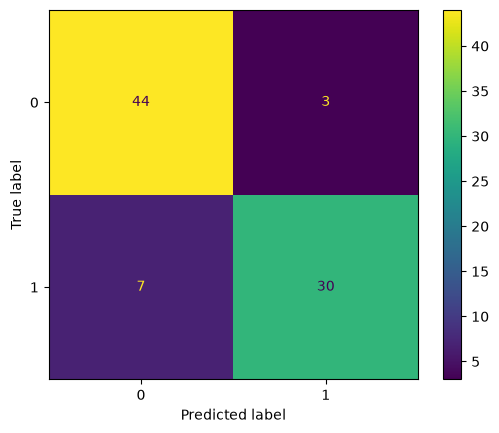

<Figure size 800x600 with 0 Axes>

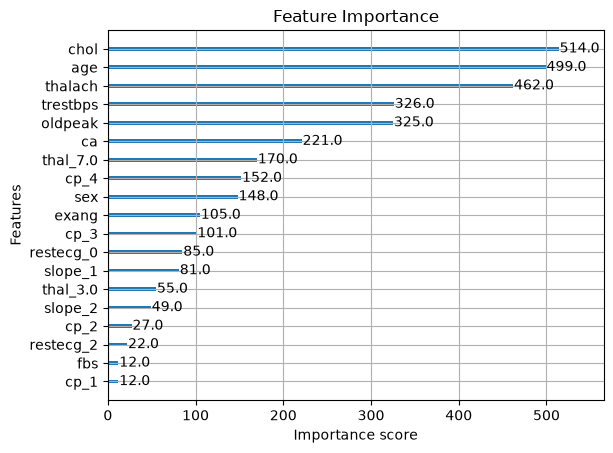

In [182]:
from sklearn.metrics import recall_score, accuracy_score, precision_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_pred_xgb = bayes_opt_xgb.predict(X_test)

recall_xgb = recall_score(y_test, y_pred_xgb)
precision_xgb = precision_score(y_test, y_pred_xgb)
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)

print('Recall:', recall_xgb)
print('Precision:', precision_xgb)
print('Accuracy:', accuracy_xgb)
cm = confusion_matrix(y_test, y_pred_xgb)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=bayes_opt_xgb.classes_)
disp.plot()

plt.figure(figsize=(8,6))
xgb.plot_importance(bayes_opt_xgb)
plt.title("Feature Importance")
plt.show()

In [183]:
#Save model 
from joblib import dump, load

dump(bayes_opt_xgb, 'models/xgboost.joblib')

# To load model back 
#loaded_model = load('xgboost.joblib')

['models/xgboost.joblib']

# Model Comparison

In [195]:
import pandas as pd

metrics = pd.DataFrame({
    'model': ["Logistic Regression (Baseline)", "Random Forest", "XGBoost"],
    "accuracy": [accuracy_lg, accuracy_rf, accuracy_xgb], 
    "recall": [recall_lg, recall_rf, recall_xgb], 
    "precision":[precision_lg, precision_rf, precision_xgb]
})

Metrics Comparison

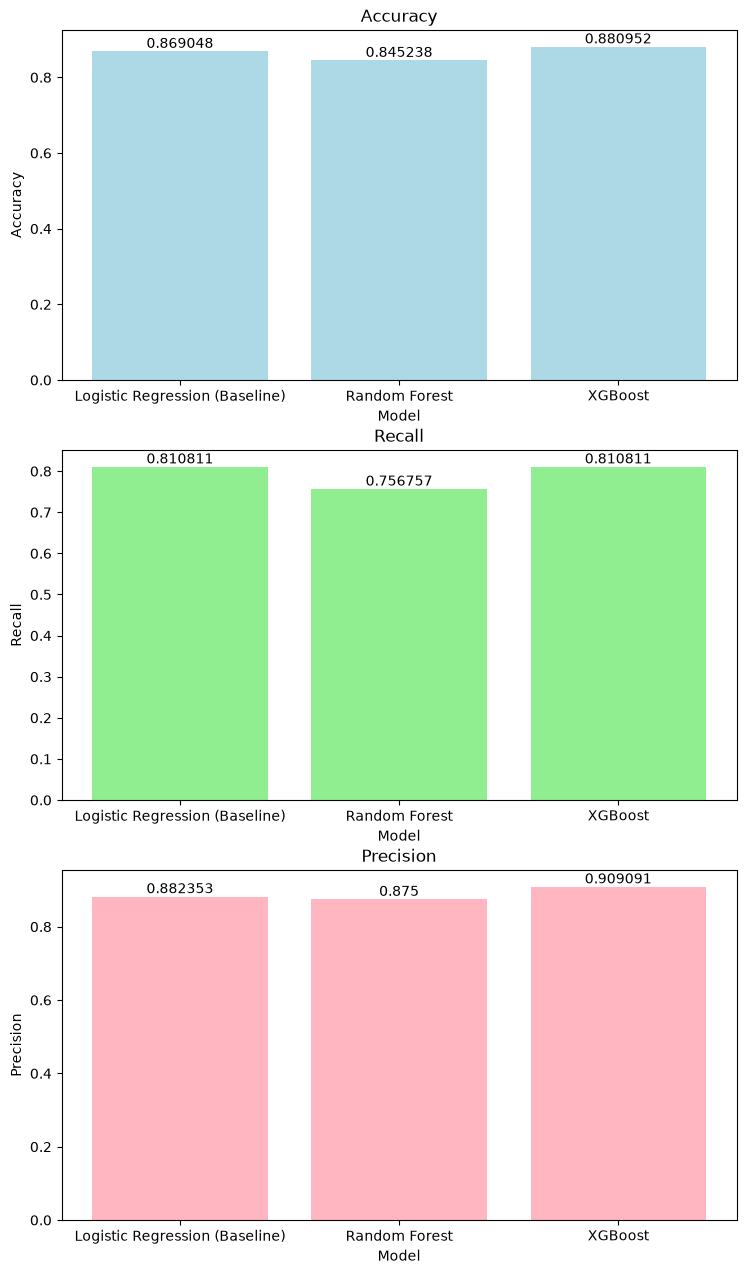

In [196]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(10,14))

a = axes[0].bar(metrics['model'], metrics['accuracy'], color='lightblue')
axes[0].set(title='Accuracy', xlabel= "Model", ylabel='Accuracy')
axes[0].bar_label(a)

r = axes[1].bar(metrics['model'], metrics['recall'], color='lightgreen')
axes[1].set(title='Recall', xlabel= "Model", ylabel='Recall')
axes[1].bar_label(r)

p = axes[2].bar(metrics['model'], metrics['precision'], color='lightpink')
axes[2].set(title='Precision', xlabel= "Model", ylabel='Precision')
axes[2].bar_label(p)

plt.subplots_adjust(bottom=0.05, right=0.8, top=0.9)
plt.show()

ROC-AUC Score

- Understanding ROC score:
    - The ROC score is a graphical representation of a classification model's performance across different thresold values
    - The ROC curve plots the true positive rate (the proportion of actual positives correctly identified by the model) and the false positive rate (the proportion of actual negatives incorrectly classified as positives)
    - A well-performing model will have a ROC curve that rises quickly towards the top-left corner, indicating a high True Positive Rate while maintaining a low False Positive Rate


- Understanding AUC score:
    - The AUC score quantifies the overall performance of the classifier by measuring the area under the ROC curve. It provides a single value that summarizes how well the model differentiates between positive and negative classes.
    - The AUC score model performance ranges:  
        - 1.0 (Perfect Model)
        - 0.9 to 1.0 (Excellent)
        - 0.8 to 0.9 (Good)
        - 0.7 to 0.8 (Fair)
        - 0.6 to 0.7 (Poor)
        - 0.5 (No Discrimination - random guessing)
    - A higher AUC score means the model is better at distinguishing between positive and negative classes. A model with an AUC of 0.5 is no better than a random classifier, whereas an AUC of 1.0 represents a perfect classifier.

</br>

> Resource: https://medium.com/@lomashbhuva/mastering-roc-curve-auc-a-comprehensive-guide-for-model-evaluation-86d557d4cf68

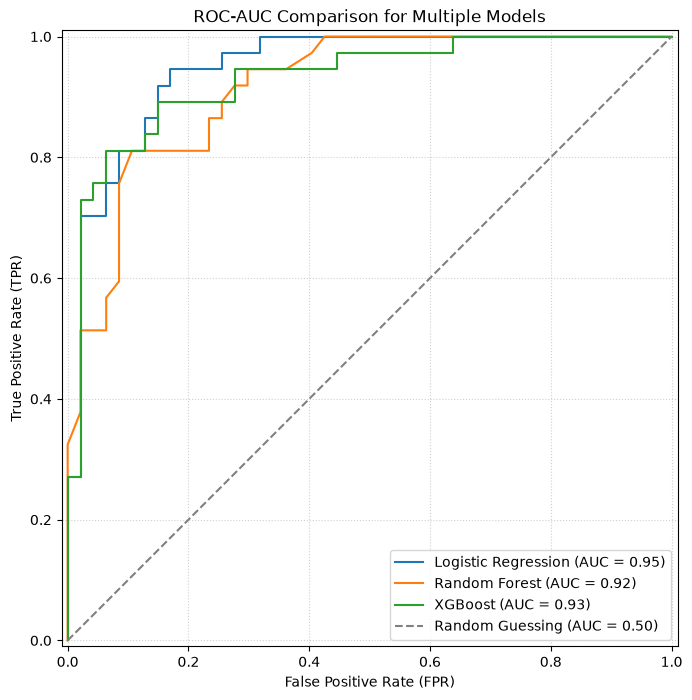

In [197]:
import numpy as np
from sklearn.metrics import RocCurveDisplay
from joblib import load

models = {
    "Logistic Regression": load('models/logistic.joblib'), 
    "Random Forest": load('models/randomforest.joblib'), 
    "XGBoost": load('models/xgboost.joblib') 
}

fig, ax = plt.subplots(figsize=(10, 8))

for name, model in models.items():
    RocCurveDisplay.from_estimator(model, X_test, y_test, ax=ax, name=name)

ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random Guessing (AUC = 0.50)") #
ax.set_title("ROC-AUC Comparison for Multiple Models")
ax.set_xlabel("False Positive Rate (FPR)")
ax.set_ylabel("True Positive Rate (TPR)")
ax.legend(loc="lower right")
ax.grid(True, linestyle=":", alpha=0.6)

plt.show()

# Analysis

| Model | Accuracy | Recall | Precision | ROC-AUC | CV F2 (train) |
|---|---|---|---|---|---|
| Logistic Regression (Baseline) | 0.869 | **0.811** | 0.882 | **0.95** | 0.763 |
| Random Forest | 0.845 | 0.757 | 0.875 | 0.92 | 0.778 |
| XGBoost (Bayesian Optimization) | **0.881** | **0.811** | **0.909** | 0.93 | **0.790** |

All three models were tuned using the F2 score, which weights recall more heavily than precision because missing a heart disease case is more costly than a false alarm. The final metrics are reported on a held-out test set of 84 patients (37 with heart disease).

**Recall.** Logistic Regression and XGBoost both correctly identified 30 of the 37 patients with heart disease, missing 7. Random Forest identified 28, missing 9, making it the weakest model on the priority metric.

**Precision and accuracy.** XGBoost produced the fewest false alarms (3), compared with 4 for both Logistic Regression and Random Forest. This gives XGBoost the highest precision and accuracy, although the difference from Logistic Regression is a single patient.

**ROC-AUC.** All three models show excellent discrimination (0.92–0.95), well above random guessing (0.50). Logistic Regression has the highest AUC, meaning it ranks patients by risk most effectively across all decision thresholds. The metrics above use the default 0.5 threshold, and lowering it would increase recall at the cost of more false alarms. The model with the best ranking is best placed to benefit from that adjustment.

**Model choice.** Logistic Regression and XGBoost perform almost identically: equal recall, a one-patient difference in false positives, and AUCs within 0.02. XGBoost achieved the highest cross-validated F2 score during tuning, but the gap is small. Given this near-tie, Logistic Regression is the preferred model. It matches XGBoost on recall, has the highest AUC, and is far more interpretable, since its coefficients show how each feature affects predicted risk. That a linear model keeps pace with the tree ensembles suggests the relationship between the features and heart disease is largely additive, and with only 196 training rows the ensembles have limited data to learn more complex interactions.

**Feature importance.** In the XGBoost model, `chol`, `age`, `thalach`, `trestbps`, and `oldpeak` were used most often to split the trees. This measure counts splits, which favours continuous features with many possible split points, so it should not be read as a ranking of clinical importance.

**Limitations.** With 84 test patients, a single patient changes recall by about 2.7 percentage points, so the differences between models are within noise. Repeated stratified cross-validation would give a more reliable comparison. In addition, the continuous features were standardized before the train/test split, so a small amount of information from the test set influenced preprocessing.